# Einleitung
Die Nähe zu Haltstellen des öffentlichen Verkehr ist eine sehr wichtiger Faktor für die Lebensqualität in Städten und Regionen des Kantons Zürichs. Wer neben einer Haltestelle wohnt spart viel Zeit im Alltag, z.B. für den Schulweg oder den Weg in die Arbeit. Auch kann man oft auch auf ein Auto verzichten. Ebenfalls profitiert man von einer hohen Flexibilität, insbesondere in der Stadt Zürich. Dort gibt von Zug bis zum Bus alles mögliche um sich schnell und effizient durch die Stadt Zürich zu bewegen.

Doch wie stark wirkt das ÖV-Netz auf die Mietpreisen von drei und vier Zimmer Wohnungen aus? In dieser Analyse untersuchen wir den Zusammenahng zwischen Fahrpläne und die Mietpreisen in verschiedenen Planungsregionen des Kantons Zürich.

Wir haben für die Datensuche viel Mühe und sind uns bewusst das sie nicht ideal sind, doch sie sind das beste was wir gefunden haben. Wir haben sogar das Statistik Amt angeschrieben und diese durften uns genauere Daten nicht rausgeben. Die meisten Daten kommen von *Opendata.swiss*. Auch haben wir die Tabelle für Region zu Gemeinde selber gemacht, um die Tabellen für die Miete und dem ÖV-Netz verbinden.

In [12]:
import pandas as pd;
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.io as pio
from IPython.display import Image, display
import os

In [22]:
# brauchts für die HeatMap
# Ist umrechnung von Koordinaten
# Ist nicht von uns gemacht sondern irgendwo auf ein Forum rauskopiert.
def lv95_to_wgs84(E, N):
    y = (E - 2600000.0) / 1000000.0
    x = (N - 1200000.0) / 1000000.0
    lat = 16.9023892 + 3.238272 * x - 0.270978 * y**2 - 0.002528 * x**2 - 0.0447 * y**2 * x - 0.0140 * x**3
    lon = 2.6779094 + 4.728982 * y + 0.791484 * y * x + 0.1306 * y * x**2 - 0.0436 * y**3
    lat = lat * 100/36
    lon = lon * 100/36
    return lat, lon

# Einlesen der Datensätze
df_zug_schweiz = pd.read_csv("data/stop-points-today_Schweiz.csv", sep=";", dtype=str)
df_zug_schweiz["E-Koordinate"] = df_zug_schweiz["E-Koordinate"].astype(float)
df_zug_schweiz["N-Koordinate"] = df_zug_schweiz["N-Koordinate"].astype(float)

# LV95 zu WGS84 Umrechnung wegen LV95 fast nur Schweiz ist
df_zug_schweiz["lat"], df_zug_schweiz["lon"] = zip(*df_zug_schweiz.apply(lambda row: lv95_to_wgs84(row["E-Koordinate"], row["N-Koordinate"]), axis=1))

fig = px.density_map(
    df_zug_schweiz,
    lat="lat",
    lon="lon",
    radius=3, # Stärke der Farbe pro Punkt
    center={"lat":46.70, "lon":8.3},
    zoom=6,
    map_style="open-street-map",
    opacity=0.4,
    title="Heatmap der Haltestellen in der Schweiz",
    width=700,
    height=500,
    color_continuous_scale="viridis"
)

fig.update_layout( # Macht das der Farbgraph links ist
    coloraxis_colorbar=dict(
        x=0.02,
        y=0.5,
        len=0.8,
        thickness=20
    )
)

#| echo: true
#| output: true

if os.getenv('QUARTO_FORMAT') != 'pdf':
    fig.show()

::: {.content-visible when-format="pdf"}
![Heatmap der Haltestellen in der Schweiz](docs/hm_s.png){width=100%}
![Heatmap der Haltestellen in des Kanton Zürich](docs/hm_z.png){width=100%}
:::

In [23]:
# Einlesen der Daten
df_zug_zurich = pd.read_csv("data/stop-points-today_zurich.csv", sep=";", dtype=str)
df_zug_zurich["E-Koordinate"] = df_zug_zurich["E-Koordinate"].astype(float)
df_zug_zurich["N-Koordinate"] = df_zug_zurich["N-Koordinate"].astype(float)

# Koordinaten Konvertrieren
df_zug_zurich["lat"], df_zug_zurich["lon"] = zip(*df_zug_zurich.apply(lambda row: lv95_to_wgs84(row["E-Koordinate"], row["N-Koordinate"]), axis=1))

fig = px.density_map(
    df_zug_zurich,
    lat="lat",
    lon="lon",
    radius=9,
    center={"lat":47.40, "lon":8.65},
    zoom=8.5,
    map_style="open-street-map",
    opacity=0.45,
    title="Heatmap der Haltestellen im Kanton Zürichs",
    width=750,
    height=500,
    color_continuous_scale="inferno"
)

fig.update_layout(
    coloraxis_colorbar=dict(
        x=0.02,
        y=0.5,
        len=0.8,
        thickness=20
    )
)

#| echo: true
#| output: true

if os.getenv('QUARTO_FORMAT') != 'pdf':
    fig.show()

# ÖV-Netz

Auf den Heatmaps sieht man alle Haltestellen. Man kann nicht genau festlegen, ob der ÖV die Preise beeinflusst, aber man kann feststellen, dass es Orte gibt, an denen es offensichtlich mehr Haltestellen gibt als an anderen Orten.
Mit dieser Bobachtung kann man folgern, dass dort, wo am dichtesten die Punkte (Haltestellen) sind, am meisten Bewegung herrscht. Menschen wollen sich dort viel und schnell von Ort zu Ort bewegen und dies führt sicherlich zu einem Aufpreis der Wohnung, da es ein Luxusgut ist, sich schnell fortzubewegen.
- In den Regionen Weinland und Zürcher Oberland gibt es wenige Haltestellen nah beieinander. Dort ist der Mietpreis tiefer, aber man muss oft für längere Pendelwege 'bezahlen'.
- Nicht so weit weg von Zürich gibt es die Regionen Pfannenstiel und Zimmerberg. Dort ist der Mietpreis viel höher, obwohl es sehr wenige Haltestellen gibt. Hier gibt es einen sogenannten "Lake-View"-Effekt. Die Heatmap misst die Quantität der Haltestellen, aber nicht die Qualität oder das Prestige. Am Zürichsee zahlt man nicht für den ÖV, sondern für den See und die Steuern.

Diese zwei Punkte zeigen, dass der ÖV nicht kein Faktor ist, der stark den Mietpreis beeinflusst.

Zusammenfassend kann man sagen, dass ein dichtes ÖV-Netz führt oft zu höheren Mieten, aber es ist nicht der einzige Grund dafür. In der Stadt Zürich ist die gute Anbindung zwar sehr super praktisch und teuer, aber in Regionen am Zürichsee sind andere Dinge wichtiger. Dort zählen die Aussicht auf den See, das Prestige und tiefe Steuern mehr als die Verbindungen. Die Daten zeigen also, dass die Nähe zu Bahn und Bus ist wichtig, aber der Blick aufs Wasser macht die Wohnungen im Kanton Zürich am teuersten.

In [7]:
df_Miet_alles = pd.read_csv("data/RegionalDaten3und4ZimmerMietpreisundProQuadratmeter.csv", sep=",")
df_Miet_Selekt= df_Miet_alles[["Region", "3-Zimmer_Gesamtmiete_CHF", "4-Zimmer_Gesamtmiete_CHF"]]
df_Miet_Selekt 

,Region,3-Zimmer_Gesamtmiete_CHF,4-Zimmer_Gesamtmiete_CHF
0,Schweiz,1370,1630
1,Kanton Zürich,1620,1910
2,Winterthur Stadt,1440,1690
3,Winterthur Umland,1440,1720
4,Weinland,1500,1680
5,Zürcher Unterland,1510,1780
6,Zürcher Oberland,1520,1790
7,Furttal,1530,1790
8,Limmattal,1550,1850
9,Knonaueramt,1590,1890


# Mietpreise
Auf der Grafik sieht man die durchschnittlichen Mietpreise für 3- und 4-Zimmer-Wohnungen in verschiedenen Regionen. Zusätzlich sind auch die Durchschnittswerte der ganzen Schweiz sowie des Kantons Zürich aufgeführt. Schon auf den ersten Blick fällt auf, dass der Pfannenstiel liegt preislich klar an der zuoberst.

Das hat mehrere Gründe. Einer der wichtigsten ist die Lage. Der Pfannenstiel grenzt direkt an den Zürichsee, und viele Wohnungen bieten eine schöne oder zumindest teilweise Seesicht, was die Mietpreise automatisch in die Höhe treibt. Gleichzeitig ist die Region nur wenige Minuten von der Stadt Zürich entfernt, was sie besonders attraktiv für Arbeitende und Studierende macht.

Auch der öffentliche Verkehr spielt eine grosse Rolle. Der Pfannenstiel ist hervorragend angebunden. Mehrere S-Bahnen fahren in kurzer Taktung nach Zürich, darunter die S6 und S7, die zuverlässig zwischen den Gemeinden am Hang, Stadelhofen und dem Hauptbahnhof fahren. Ergänzt wird das Ganze durch zahlreiche Buslinien, die auch höher gelegene Wohnquartiere gut erreichen und die Bewohner bequem zu den S-Bahn-Stationen am See bringen. So ist man selbst ohne Auto schnell und flexibel unterwegs.

Nicht zuletzt bietet die Umgebung viel Natur. Rund um den Pfannenstiel gibt es Wälder, Wanderwege und ruhige Gebiete, die die Wohnqualität zusätzlich erhöhen. Die Mischung aus See, Natur, Nähe zur Stadt und hervorragender ÖV-Anbindung sorgt dafür, dass die Nachfrage nach Wohnungen besonders hoch ist und darum liegen die Mietpreise deutlich über dem Durchschnitt.

Das ganze zeigt, dass das öffentliche Verkehr ist nicht der einzige Faktor des Mietpreises einer Wohnung.

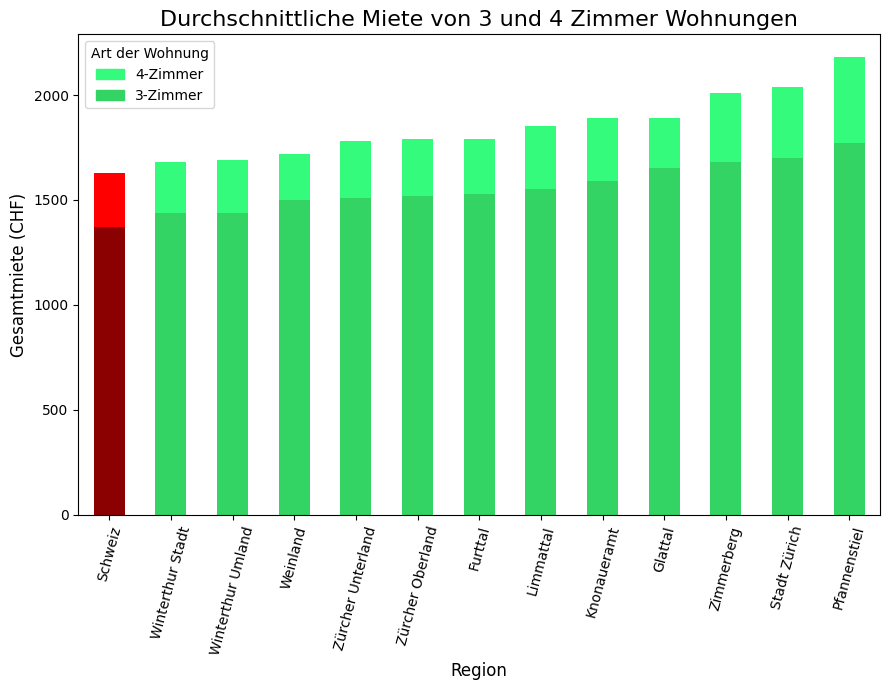

In [8]:
df_Miet_Selekt= df_Miet_alles[["Region", "3-Zimmer_Gesamtmiete_CHF", "4-Zimmer_Gesamtmiete_CHF"]]
df_Miet_Selekt = df_Miet_Selekt.set_index('Region')
df_Miet_Selekt = df_Miet_Selekt.drop("Kanton Zürich", errors='ignore')

regions = df_Miet_Selekt.index

# Frarben setzen für den Plots
colors = ["#35fb7c"] * len(regions)
colors_2 = ["#33d463"] * len(regions)

specials = {"Schweiz": "red"}
specials_2 = {"Schweiz": "darkred"}

# Stange "Schweiz" Rot einfärben
for i, region in enumerate(regions):
    if region in specials:
        colors[i] = specials[region]
    if region in specials_2:
        colors_2[i] = specials_2[region]

# Heller Plot
ax = df_Miet_Selekt['4-Zimmer_Gesamtmiete_CHF'].sort_values(ascending=True).plot(
    kind='bar', 
    figsize=(9, 7),
    rot=90,
    color=colors
)

# Dunkler Plot
df_Miet_Selekt['3-Zimmer_Gesamtmiete_CHF'].sort_values(ascending=True).plot(
    kind='bar', 
    ax=ax,
    rot=75, 
    color=colors_2,
    label='3-Zimmer'
)

# layout für den Plot
plt.title('Durchschnittliche Miete von 3 und 4 Zimmer Wohnungen', fontsize=16)
plt.ylabel('Gesamtmiete (CHF)', fontsize=12)
plt.xlabel('Region', fontsize=12)
legend_handles = [
    mpatches.Patch(color="#35fb7c", label='4-Zimmer'),
    mpatches.Patch(color="#33d463", label='3-Zimmer')
]
plt.legend(handles=legend_handles, title='Art der Wohnung')

plt.tight_layout()
plt.show()

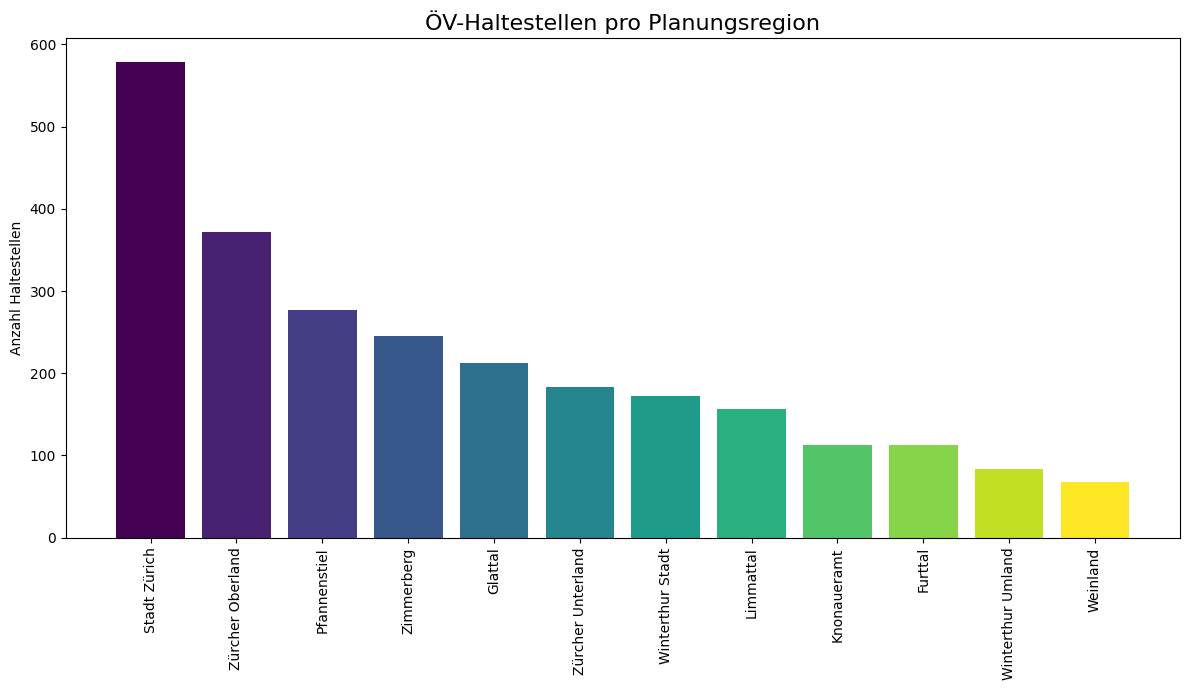

In [9]:
df_haltestellen = pd.read_csv("data/stop-points-today_zurich.csv", sep=";", dtype=str)
df_gemeinden = pd.read_csv("data/gemeinde_region.csv", sep=",", dtype=str)
df_gemeinden
df_beide = df_haltestellen.merge(
    df_gemeinden[['BFS', 'Planungsregion']],
    left_on='Gemeindenummer BFS',
    right_on='BFS',
    how='left'
)
counts = df_beide.groupby('Planungsregion').size().sort_values(ascending=False) # Sortieren

plt.figure(figsize=(12, 7))

# Macht farben und sortiert sie schön
colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))

plt.bar(counts.index, counts.values, color=colors)

plt.xticks(rotation=90)
plt.title("ÖV-Haltestellen pro Planungsregion", fontsize=16)
plt.ylabel("Anzahl Haltestellen")

plt.tight_layout()
plt.show()


# Haltestellen Pro Region

In dieser Grafik kann man sehr gut sehen, wie die Haltestellen im Kanton Zürich verteilt sind. Die Balekn zeigen sofort einen grossen Unterschied zwischen den Regionen. Die Stadt Zürich steht ganz oben auf der Liste und hat mit fast 600 Haltestellen am meisten Haltestelen. Das zeigt uns, dass in der Stadt die Mobilität extrem wichtig ist und die Menschen dort sehr viele Möglichkeiten haben, sich schnell zu bewegen.

Nach der Stadt kommt das Zürcher Oberland auf dem zweiten Platz. Obwohl diese Region auch viele Haltestellen hat, sieht man trotzdem eine grosse Lücke zur Stadt Zürich. Danach sinken die Zahlen immer weiter ab. Regionen wie das Pfannenstiel, Zimmerberg oder das Glattal liegen eher im Mittelfeld. Das ist interessant, weil wir ja schon wissen, dass Orte wie das Pfannenstiel bei den Mietpreisen ganz oben sind, obwohl sie hier bei der Anzahl der Haltestellen gar nicht gewinnen.

Am Ende der Grafik sieht man das Weinland und das Winterthur Umland. Diese Orte haben die wenigsten Haltestellen, oft sind es sogar weniger als 100 Stück. Man kann also feststellen, dass die Infrastruktur im Kanton sehr ungleich ist. Während man in der Stadt an fast jeder Ecke eine Haltestelle findet, muss man auf dem Land viel weiter suchen. Das bedeutet für die Bewohner dort, dass sie oft längere Wege haben oder mehr Zeit einplanen müssen, um von einem Ort zum anderen zu kommen.

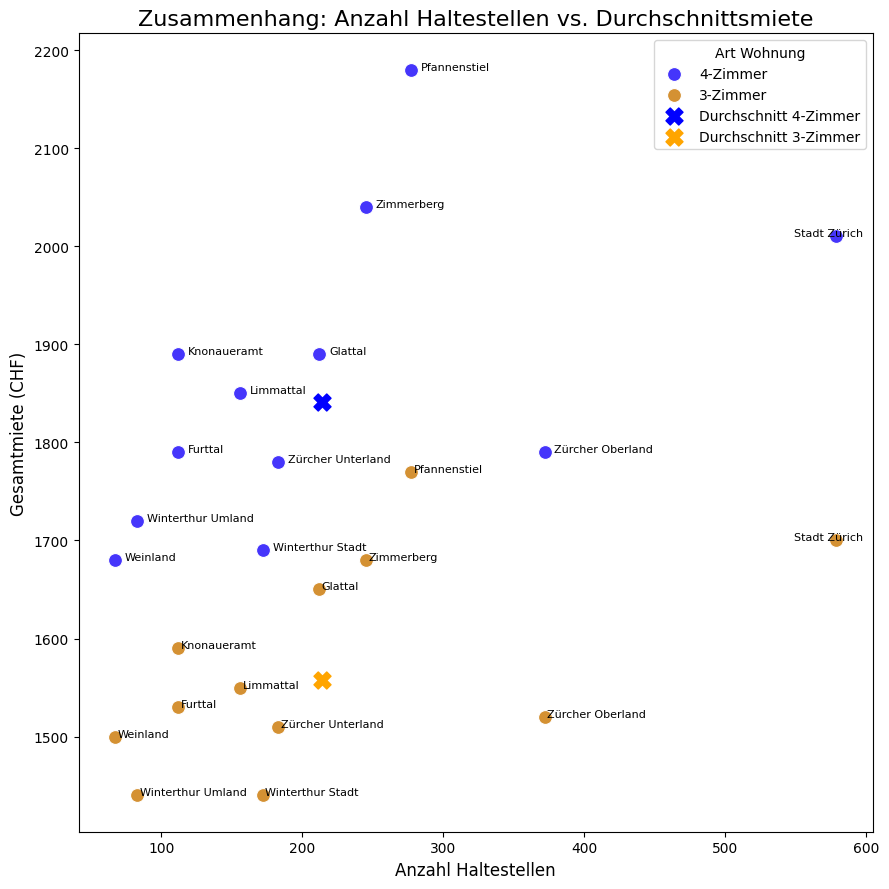

In [10]:
# Daten Einlesen
df_Miet_Selekt = df_Miet_alles[["Region", "3-Zimmer_Gesamtmiete_CHF", "4-Zimmer_Gesamtmiete_CHF"]]
df_Miet_Selekt = df_Miet_Selekt.set_index('Region')
df_haltestellen = pd.read_csv("data/stop-points-today_zurich.csv", sep=";", dtype=str)
df_gemeinden = pd.read_csv("data/gemeinde_region.csv", sep=",", dtype=str)
df_beide = df_haltestellen.merge(
    df_gemeinden[['BFS', 'Planungsregion']],
    left_on='Gemeindenummer BFS',
    right_on='BFS',
    how='left'
)
df_haltestellen_count = df_beide.groupby('Planungsregion').size().reset_index(name='Haltestellen')
df_plot = df_Miet_Selekt.merge(df_haltestellen_count, left_index=True, right_on='Planungsregion', how='left')
df_plot = df_plot[df_plot['Planungsregion'] != 'Kanton Zürich']

plt.figure(figsize=(9,9))

sns.scatterplot( # Scatterplott machen für die 4 Zimmer Wohnungen
    data=df_plot,
    x='Haltestellen',
    y='4-Zimmer_Gesamtmiete_CHF',
    s=100,
    color="#4535fb",
    label='4-Zimmer'
)

sns.scatterplot( # Das gleiche hier aber für die 3 Zimmer Wohnungen
    data=df_plot,
    x='Haltestellen',
    y='3-Zimmer_Gesamtmiete_CHF',
    s=100,
    color="#d49133",
    label='3-Zimmer'
)

avg_3_zimmer = df_plot['3-Zimmer_Gesamtmiete_CHF'].mean()  # Durschnittberechnungen
avg_4_zimmer = df_plot['4-Zimmer_Gesamtmiete_CHF'].mean()
avg_haltestellen = df_plot['Haltestellen'].mean()

# Durschnitt hinzufügen in den Plot
plt.scatter(avg_haltestellen, avg_4_zimmer, s=150, color='blue', marker='X', label='Durchschnitt 4-Zimmer')
plt.scatter(avg_haltestellen, avg_3_zimmer, s=150, color='orange', marker='X', label='Durchschnitt 3-Zimmer')

x_max = df_plot['Haltestellen'].max()

# SChrift versetzen damit es nicht im Punkt ist
for i, row in df_plot.iterrows():
    x_offset_4 = 7 if row['Haltestellen'] < x_max - 20 else -30
    x_offset_3 = 2 if row['Haltestellen'] < x_max - 20 else -30
    
    plt.text(row['Haltestellen'] + x_offset_4, row['4-Zimmer_Gesamtmiete_CHF'], row['Planungsregion'], fontsize=8)
    plt.text(row['Haltestellen'] + x_offset_3, row['3-Zimmer_Gesamtmiete_CHF'], row['Planungsregion'], fontsize=8)


plt.title('Zusammenhang: Anzahl Haltestellen vs. Durchschnittsmiete', fontsize=16)
plt.xlabel('Anzahl Haltestellen', fontsize=12)
plt.ylabel('Gesamtmiete (CHF)', fontsize=12)
plt.legend(title='Art Wohnung')
plt.tight_layout()
plt.show()


# Vergleich zwischen Anzahl Haltestellen und Miete
Wenn wir uns die Grafik anschauen, bemerken wir sofort einen Trend. Wer eine gute Verbindung zum ÖV will, muss meistens mehr Miete zahlen. Wir haben hier den Vergleich zwischen der Anzahl der Haltestellen und den Mietpreisen im Kanton Zürich für 3- und 4-Zimmer-Wohnungen.

Im Grunde gilt, je mehr Haltestellen es gibt, desto teurer wird es. Die Stadt Zürich ist da am besten mit fast 600 Haltestellen, aber dafür sind die Mieten dort auch extrem hoch. Am anderen Ende sehen wir Regionen wie das Weinland oder das Umland von Winterthur. Dort gibt es weniger als 100 Haltestellen und die Mieten sind viel niedriger. Wir denken, dass das logisch ist, weil ein guter Fahrplan das Leben einfacher macht und deshalb mehr Leute dort wohnen wollen.

Es gibt aber auch Ausnahmen, die uns aufgefallen sind. Am Pfannenstiel gibt es zum Beispiel viel weniger Haltestellen als in der Stadt, aber die Mieten sind trotzdem mega hoch, teilweise sogar höher als in Zürich. Das zeigt uns, dass der Fahrplan nicht alles ist. Manche Leute zahlen lieber mehr für eine schöne Aussicht oder Ruhe in der Natur als für einen Bahnhof in der Nähe.

Ausserdem sehen wir den Unterschied bei der Wohnungsgrösse. Die blauen Punkte für 4 Zimmer liegen fast immer über den braunen Punkten für 3 Zimmer. Im Schnitt zahlen wir für das zusätzliche Zimmer im Kanton etwa 280 Franken mehr pro Monat.

Unser Fazit ist, dass ein dichter Fahrplan die Gegend attraktiv macht und die Preise hochtreibt. Wer Geld sparen will, zieht eher dorthin, wo der Bus seltener fährt. Der ÖV ist also ein wichtiger Faktor für die Wohnkosten, ausser in Luxuslagen, wo andere Sachen wichtiger sind.